In [1]:
%load_ext autoreload
%autoreload 2

# import known packages
import pickle
import gzip
import numpy as np

import os
from tenpy.tools import hdf5_io
import h5py

from matplotlib import pyplot as plt

# from scipy import signal

from tenpy.networks.mps import MPS

# import adhoc packages
from qphaset.phases import gstates_to_rdms_matrix, gstates_to_rdms_matrix_qs_mps, phases_vfield
from qphaset.models import get_bond_dim_qs_mps
from qphaset.plotting import plot_grad_g_angle_stream, plot_grad_g_angle4, plot_grad_g_angle_sin_cos

In [2]:
# choose which tensor network package to use:

# tnpy, qsmps = True, False
tnpy, qsmps = False, True

## Phase transitions detection
Implemementation of one of the main results of the paper.

In [3]:
model_name = 'ANNNI'
device = 'pc'
# device = 'ngt'

if device == 'pc':
    device_path = "D:/code"
elif device == 'ngt':
    device_path = "/eos/user/f/fdimarca"

# dmrg params
chi = 100 # bond dimension
c1 = 1e-3 # eps symm. break.
if model_name == 'ANNNI':
    path_to_tensor = f"{device_path}/projects/2_ANNNI/results/data"
    path_to_figures = f"{device_path}/projects/2_ANNNI/figures"
    axis_name = ('k', 'h')

elif model_name == 'Cluster':
    path_to_tensor = f"{device_path}/projects/3_CLUSTER/results/data"
    path_to_figures = f"{device_path}/projects/3_CLUSTER/figures"
    axis_name = ('k', 'h')

elif model_name == 'Rydberg':
    path_to_tensor = f"{device_path}/projects/4_RYDBERG/results/data"
    path_to_figures = f"{device_path}/projects/4_RYDBERG/figures"
    axis_name = ('$\\Delta/\\Omega$', '$R_b/a$')

else:
    raise SyntaxError("Choose a valid model among 'ANNNI', 'Cluster', and 'Rydberg'")


# List all files in the directory
files = os.listdir(path_to_tensor)

# Filter for .pkl and .h5 files
pkl_and_h5_files = [os.path.join(path_to_tensor, file) for file in files if file.endswith('.pkl') or file.endswith('.h5')]

# Print the list of file names
for lab, file in enumerate(pkl_and_h5_files):
    print(f"File: {file} has these metadata:")
    print(f"Choose this file with label {lab}")
    if file.endswith('.pkl'):
        with gzip.open(file, 'rb') as f:
            data = pickle.load(f)
            params = data['params']
            l, n = data['l'], data['n']
            gstates = data['gstates']
            stats = data['stats']
            model = data['model_name']
        params_extent = np.concatenate([np.min(params, axis=0), np.max(params, axis=0)])
        params_extent = tuple(params_extent[[0, 2, 1, 3]])
    
    if file.endswith('.h5'):
        with h5py.File(file, "r") as f:
            data = hdf5_io.load_from_hdf5(f)
            params_extent = data['params_extent']
            l, n = data['l'], data['n']
            gstates = data['gstates']
            model = data['info']['model_type']
            times = data['times']

    print(f"Model: {model}, Chain length: {l}, points in the grid per side: {n}")
    print(f"Param_extent: {params_extent}")
    print(f"\n#############################\n\n")

File: D:/code/projects/2_ANNNI/results/data\ANNNI_L_10_lambda_1_0.5-0.8_lambda_2_0.5-0.8_npoints_3x3.pkl has these metadata:
Choose this file with label 0
Model: ANNNI, Chain length: 10, points in the grid per side: 3
Param_extent: (np.float64(0.5), np.float64(0.8), np.float64(0.5), np.float64(0.8))

#############################


File: D:/code/projects/2_ANNNI/results/data\ANNNI_L_10_lambda_1_0.5-0.8_lambda_2_0.5-0.8_npoints_3x3.h5 has these metadata:
Choose this file with label 1
Model: ANNNI, Chain length: 10, points in the grid per side: 3
Param_extent: (np.float64(0.5), np.float64(0.8), np.float64(0.5), np.float64(0.8))

#############################


File: D:/code/projects/2_ANNNI/results/data\ANNNI_L_11_lambda_1_0.5-0.8_lambda_2_0.5-0.8_npoints_3x3.pkl has these metadata:
Choose this file with label 2
Model: ANNNI, Chain length: 11, points in the grid per side: 3
Param_extent: (np.float64(0.5), np.float64(0.8), np.float64(0.5), np.float64(0.8))

#############################



In [4]:
label = 5
file = pkl_and_h5_files[label]

if file.endswith('.pkl'):
        with gzip.open(file, 'rb') as f:
            data = pickle.load(f)
            params = data['params']
            l, n = data['l'], data['n']
            gstates = data['gstates']
            stats = data['stats']
            # model = data['model_name']
        params_extent = np.concatenate([np.min(params, axis=0), np.max(params, axis=0)])
        params_extent = tuple(params_extent[[0, 2, 1, 3]])
    
if file.endswith('.h5'):
    with h5py.File(file, "r") as f:
        data = hdf5_io.load_from_hdf5(f)
        params_extent = data['params_extent']
        l, n = data['l'], data['n']
        gstates = data['gstates']
        model = data['info']['model_type']
        times = data['times']

print(f"Model: {model}, Chain length: {l}, points in the grid per side: {n}")
print(f"Param_extent: {params_extent}")
print(f"\n#############################\n\n")

def sanitize_state(state):
    # ensure flat list of arrays
    return [np.array(t) for t in state]

gstates = [
    sanitize_state(state)
    for row in gstates
    for state in (row if isinstance(row, (list, np.ndarray)) else [row])
]


Model: ANNNI, Chain length: 12, points in the grid per side: 30
Param_extent: (np.float64(0.5), np.float64(2.1), np.float64(0.01), np.float64(1.6))

#############################




In [5]:
import types
if isinstance(gstates[0], (types.BuiltinFunctionType, types.BuiltinMethodType)):
    gstates = [gstate() for gstate in gstates]

In [6]:
# Select sites for the partial trace (gstates -> rdms, ie ground states to reduced density matrices).
# Note the concept of site depends on the model. For example in the case of models based on the
# class SpinChainNNN, the site corresponds to 2 qubits.

sites = [(l // 2) - 2, (l // 2) - 1, l // 2, (l // 2) + 1, (l // 2) + 2]
sites = [(l // 2) - 1, l // 2, (l // 2) + 1]
# sites = [l // 2, (l // 2) + 1]
# sites = [l // 2]

if tnpy:
    rdms = gstates_to_rdms_matrix(gstates, sites=sites)
elif qsmps:
    rdms = gstates_to_rdms_matrix_qs_mps(gstates, sites=sites, generalized=True)

rdm comp: 900: 100%|██████████| 900/900 [00:20<00:00, 43.21it/s]


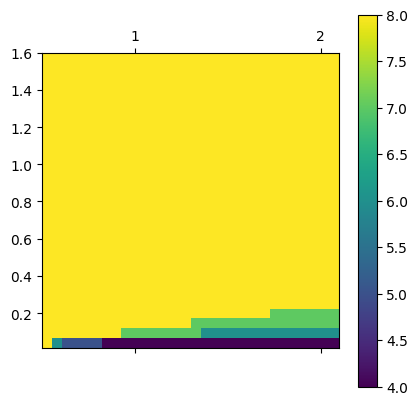

In [7]:
# Plot RDMs ranks. This is useful to study the problem of the singularities
# of the Quantum Fisher Information Matrix.

rdm_ranks = np.reshape(rdms, (-1, ) + rdms.shape[2:])
rdm_ranks = [np.linalg.matrix_rank(mat, hermitian=True) for mat in rdm_ranks]
rdm_ranks = np.reshape(rdm_ranks, rdms.shape[:2])
plt.matshow(rdm_ranks, origin='lower', extent=params_extent)
plt.colorbar()

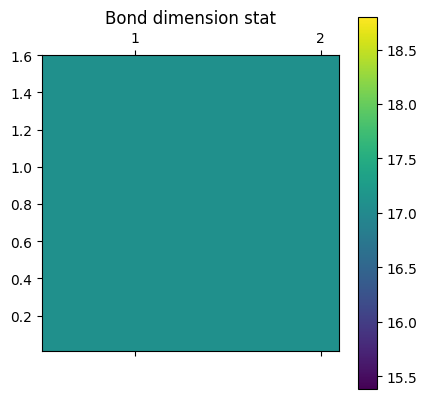

In [8]:
# Plot bond dimension.
if tnpy:
    bond_dim_map = np.array([np.mean(psi.chi) for psi in gstates])
    bond_dim_map = bond_dim_map.reshape((n, n))
    plt.matshow(bond_dim_map, origin='lower', extent=params_extent)
    plt.title('Bond dimension stat')
    plt.colorbar()
elif qsmps:
    # TODO for now we save arrays instead of objects of the class MPS
    bond_dim_map = np.array([np.mean(get_bond_dim_qs_mps(psi)) for psi in gstates])
    bond_dim_map = bond_dim_map.reshape((n, n))
    plt.matshow(bond_dim_map, origin='lower', extent=params_extent)
    plt.title('Bond dimension stat')
    plt.colorbar()

In [9]:
eps = params[1, 0] - params[0, 0]
eps

np.float64(0.05517241379310345)

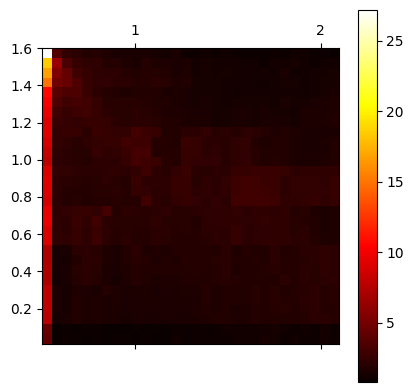

In [10]:
# Plot execution time per pixel (DMRG runtime).

plt.matshow(np.array(stats['times']).reshape((n, n))[::-1], cmap='hot', origin='lower', extent=params_extent)
plt.colorbar()

In [11]:
# Grad laplacian filter with upsampling
grad_g = phases_vfield(rdms)

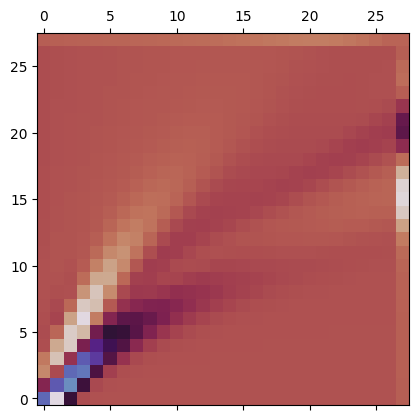

In [12]:
# *** Scaling behaviour (experimental) ***

dlog_g = phases_vfield(rdms, log_g=True, scale=1)

from qphaset.models import params_2d_lattice
xy = params_2d_lattice(params_extent[:2], params_extent[2:], n1=len(dlog_g), n2=len(dlog_g))
xy = np.reshape(xy, (len(dlog_g), ) * 2 + (2, ))
# TODO Double check real/imag association with x, y!
nu = xy[:, :, 0] * np.real(dlog_g) + xy[:, :, 1] * np.imag(dlog_g)

# Note the values should not be interpreted directly since the numerical derivative
# is mul by some const factor.
plt.matshow(nu, origin='lower', cmap='twilight')

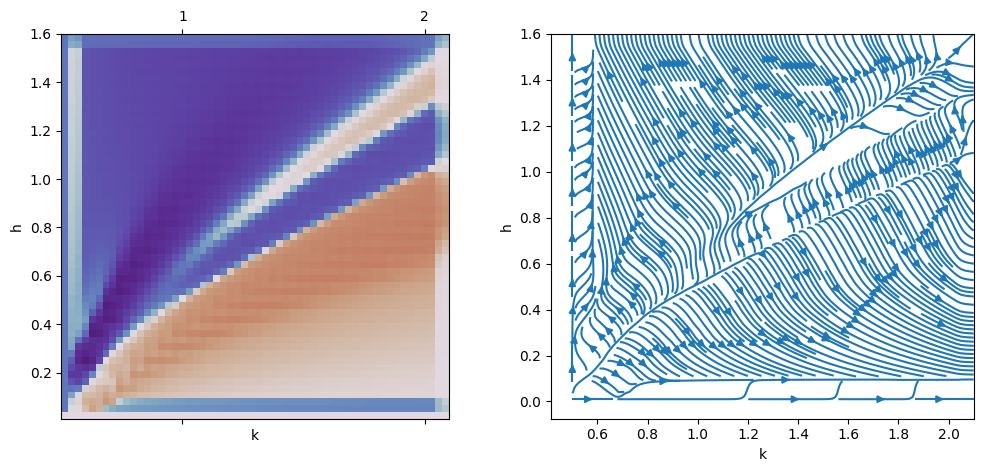

In [13]:
plot_grad_g_angle_stream(grad_g, params_extent=params_extent, theory_lines=False);

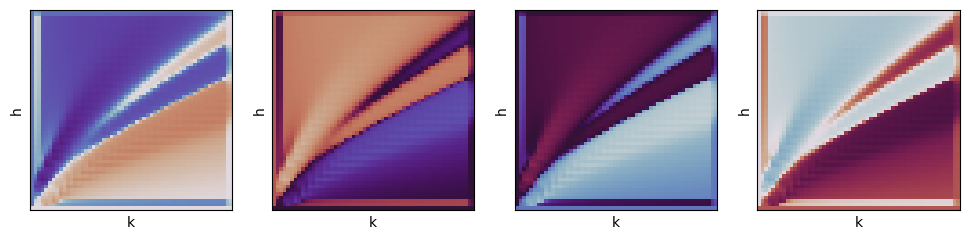

In [14]:
plot_grad_g_angle4(grad_g, params_extent=params_extent);

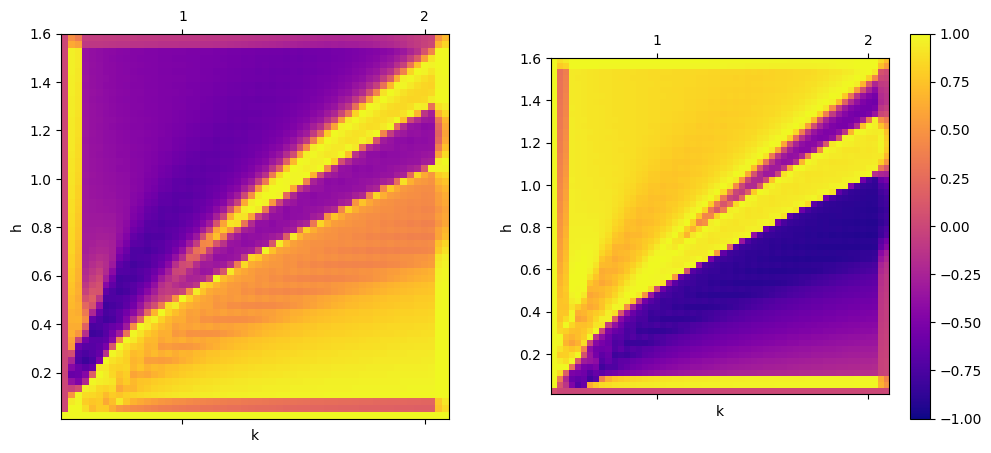

In [15]:
plot_grad_g_angle_sin_cos(grad_g, params_extent=params_extent);